In [103]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import d2l
from d2l import torch as d2l
import matplotlib.pyplot as plt

# Build Dataset

In [104]:
num_data = 1024
num_classes = 4

X = np.zeros((num_data, num_classes))
Y = np.zeros((num_data, num_classes, num_classes))

for i in range(num_data):
    x_i = np.random.random((num_classes)) * 100  # 0~100 float
    sorted_indices = np.argsort(x_i) 
    y_i = np.zeros((num_classes, num_classes))

    for rank, idx in enumerate(sorted_indices):
        y_i[rank, idx] = 1 

    X[i, :] = x_i
    Y[i, :, :] = y_i

# split dataset into train & test
split_ratio = 0.8
split_idx = int(split_ratio * num_data)
train_x = X[:split_idx]
train_y = Y[:split_idx]
valid_x = X[split_idx:]
valid_y = Y[split_idx:]

class MyDataModule(d2l.DataModule):
    def __init__(self, train_x, train_y, valid_x, valid_y, batch_size):
        super().__init__()
        self.save_hyperparameters()
        
        self.train_x = torch.tensor(train_x, dtype=torch.float32)
        self.train_y = torch.tensor(train_y, dtype=torch.float32)
        self.valid_x = torch.tensor(valid_x, dtype=torch.float32)
        self.valid_y = torch.tensor(valid_y, dtype=torch.float32)
    
    def get_dataloader(self, train):
        if train:
            dataset = torch.utils.data.TensorDataset(self.train_x, self.train_y)
        else:
            dataset = torch.utils.data.TensorDataset(self.valid_x, self.valid_y)
        
        return torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=train)


# Build Model

In [ ]:
# i-th number prediction
class MLP_Sorting(d2l.Module):
    def __init__(self, num_classes, lr, dropout_rate=0.1):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Linear(num_classes, 4 * num_classes),
            nn.BatchNorm1d(4 * num_classes),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(4 * num_classes, 8 * num_classes),
            nn.BatchNorm1d(8 * num_classes),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(8 * num_classes, 8 * num_classes),
            nn.BatchNorm1d(8 * num_classes),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(8 * num_classes, 4 * num_classes),
            nn.BatchNorm1d(4 * num_classes),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(4 * num_classes, num_classes),
        )
    
    def forward(self, x):
        return self.net(x)
    
    def loss(self, y_hat, y):
        return nn.CrossEntropyLoss()(y_hat, y)
    
    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr)



# train

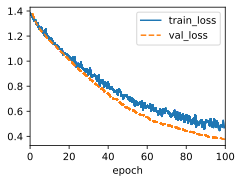

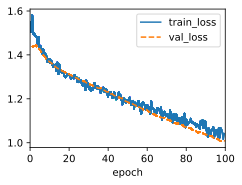

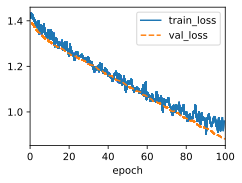

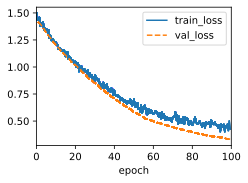

In [126]:
lr = 2e-4
batch_size = 64
epochs = 100

models = []
data_modules = []

for i in range(num_classes):  # num_classes = 10
    model = MLP_Sorting(num_classes, lr=lr)
    target_y = train_y[:, i, :].reshape(train_x.shape)
    val_y_i = valid_y[:, i, :].reshape(valid_x.shape)
    
    data_module = MyDataModule(train_x, target_y, valid_x, val_y_i, batch_size)
    
    trainer = d2l.Trainer(max_epochs=epochs)
    trainer.fit(model, data_module)
    
    models.append(model)
    data_modules.append(data_module)


# validation

tensor([[ 5.6843, 73.6678, 49.1250, 83.2520]])
tensor([[0.9780, 0.0075, 0.0076, 0.0068]])
tensor([[0.2092, 0.1155, 0.5560, 0.1193]])
tensor([[0.0260, 0.5906, 0.2158, 0.1676]])
tensor([[0.0575, 0.1316, 0.0544, 0.7565]])


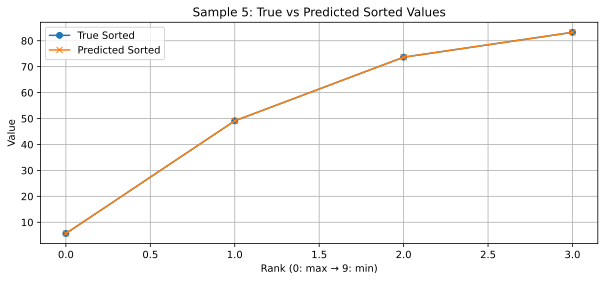

In [127]:
# 예시: i번째 validation 샘플
i = 5
x = torch.tensor(valid_x[i], dtype=torch.float32).reshape(1, -1)  # shape: (1, 10)

# 모델별 예측: 0등 ~ 9등 위치에 올 인덱스
y_hat_indices = []

print(x)
for model in models:
    with torch.no_grad():
        pred = model(x)  # shape: (1, 10), 확률 분포
        pred_exp = torch.exp(pred)
        print(pred_exp/pred_exp.sum())
        idx = torch.argmax(pred, dim=1).item()  # 가장 높은 확률의 인덱스
        y_hat_indices.append(idx)

# 예측 인덱스를 이용해 원래 x 값을 정렬
x_hat_sorted = valid_x[i][y_hat_indices]        # 모델이 예측한 순서대로 정렬한 값
x_true_sorted = np.sort(valid_x[i])[::]       # 실제 정답 (내림차순 정렬)

# 시각화: 정답 vs 예측
plt.figure(figsize=(10, 4))
plt.plot(x_true_sorted, label='True Sorted', marker='o')
plt.plot(x_hat_sorted, label='Predicted Sorted', marker='x')
plt.title(f'Sample {i}: True vs Predicted Sorted Values')
plt.xlabel('Rank (0: max → 9: min)')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


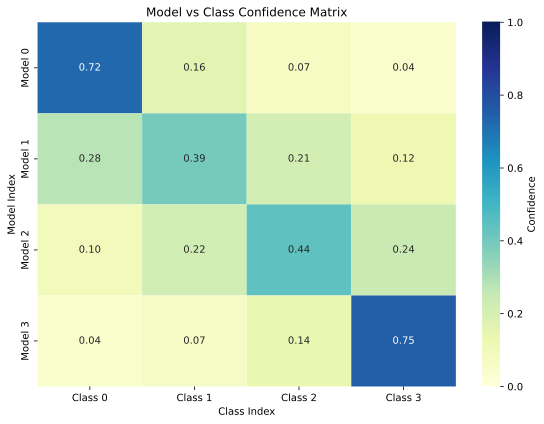

In [128]:
num_samples = valid_x.shape[0]
num_models = len(models)  # = num_classes
num_classes = valid_x.shape[1]

acc_matrix = np.zeros((num_models, num_classes))  # (model_rank, sorted_input_position)

for model_idx, model in enumerate(models):
    acc_list = []  # 이 모델에 대한 (samples, num_classes) 저장용

    for sample_idx in range(num_samples):
        x = torch.tensor(valid_x[sample_idx], dtype=torch.float32).reshape(1, -1)

        with torch.no_grad():
            pred = model(x)
            pred_exp = torch.exp(pred)
            confidence = (pred_exp / pred_exp.sum()).squeeze().numpy()  # (num_classes,)

        # 정렬된 input 인덱스를 가져옴
        sorted_indices = np.argsort(valid_x[sample_idx])[::]  # 오름차순 정렬

        # confidence를 정렬된 input 순서에 따라 재배치
        reordered_confidence = confidence[sorted_indices]

        acc_list.append(reordered_confidence)

    # 모델 i에 대해 전체 sample 평균
    acc_list = np.stack(acc_list)  # shape: (num_samples, num_classes)
    acc_matrix[model_idx, :] = acc_list.mean(axis=0)  # sample dimension 평균

import seaborn as sns
import matplotlib.pyplot as plt

model_labels = [f"Model {i}" for i in range(acc_matrix.shape[0])]
class_labels = [f"Class {j}" for j in range(acc_matrix.shape[1])]

plt.figure(figsize=(8, 6))
sns.heatmap(
    acc_matrix,
    annot=True, fmt=".2f",
    cmap="YlGnBu",
    vmin=0, vmax=1,
    xticklabels=class_labels,
    yticklabels=model_labels,
    cbar_kws={"label": "Confidence"}
)
plt.title("Model vs Class Confidence Matrix")
plt.xlabel("Class Index")
plt.ylabel("Model Index")
plt.tight_layout()
plt.show()



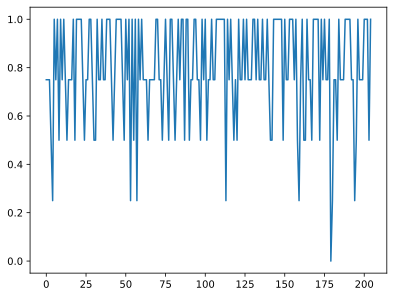

In [140]:
acc_list = []
for i in range(len(valid_x)):
    x = torch.tensor(valid_x[i], dtype=torch.float32).reshape(1, -1)  # shape: (1, 10)
    y = valid_y[i]

    # 모델별 예측: 0등 ~ 9등 위치에 올 인덱스
    y_hat_indices = []

    acc = 0
    for j, model in enumerate(models):
        with torch.no_grad():
            pred = model(x)  # shape: (1, 10), 확률 분포
            pred_exp = torch.exp(pred)
            idx = torch.argmax(pred, dim=1).item()  # 가장 높은 확률의 인덱스
            ans = np.zeros((num_classes,))
            ans[idx] = 1
            y_j = valid_y[i][j]

            acc += np.dot(ans, y_j)

    acc = acc/len(models)
    acc_list.append(acc)

plt.plot(acc_list, label='acc_list')
plt.show()

In [141]:
acc_np = np.array(acc_list)
acc_mean = acc_np.mean()
acc_stdev = acc_np.std()
print(f'acc_mean={acc_mean}, acc_stdev={acc_stdev}')

acc_mean=0.7975609756097561, acc_stdev=0.21211801234224265
